<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Lumped_Element_Quantum_Circuit_Schematic_Tunable_Gmon_Coupler_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
!uv pip install schemdraw graphviz matplotlib ipython

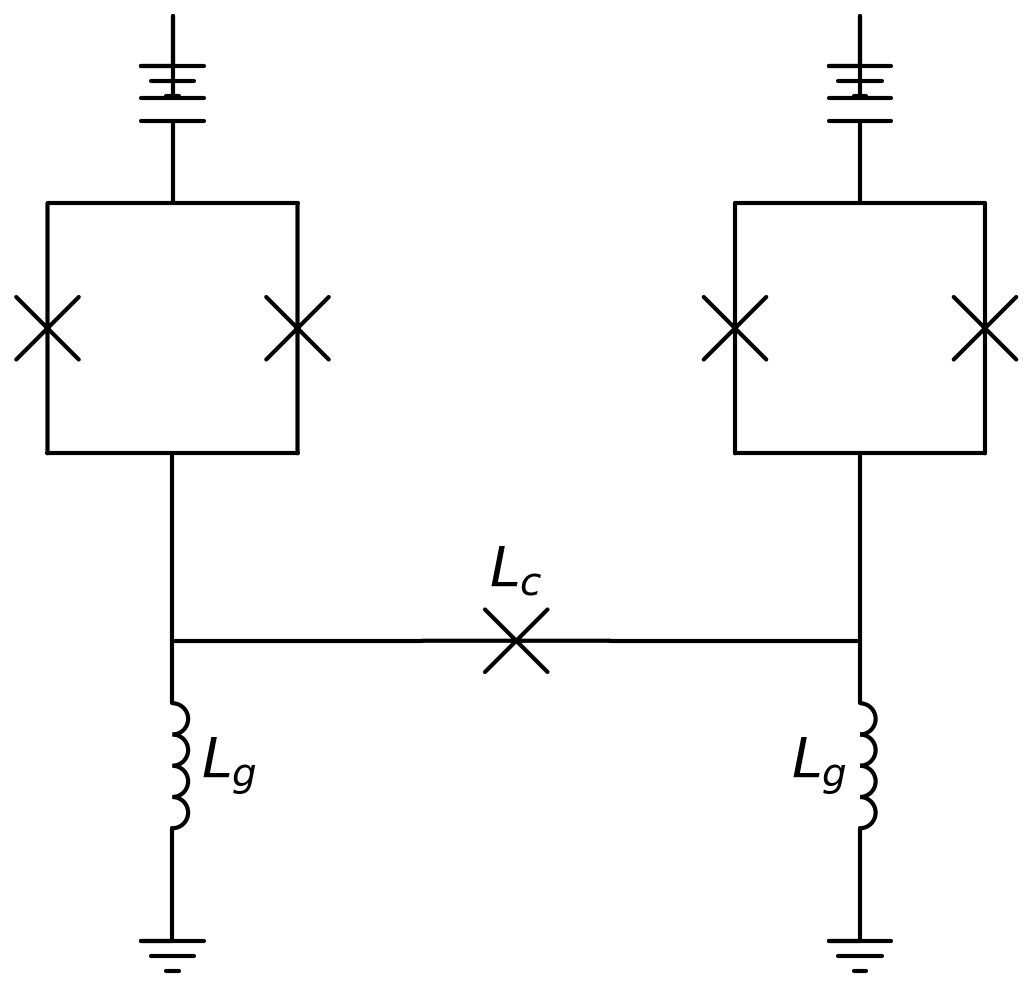

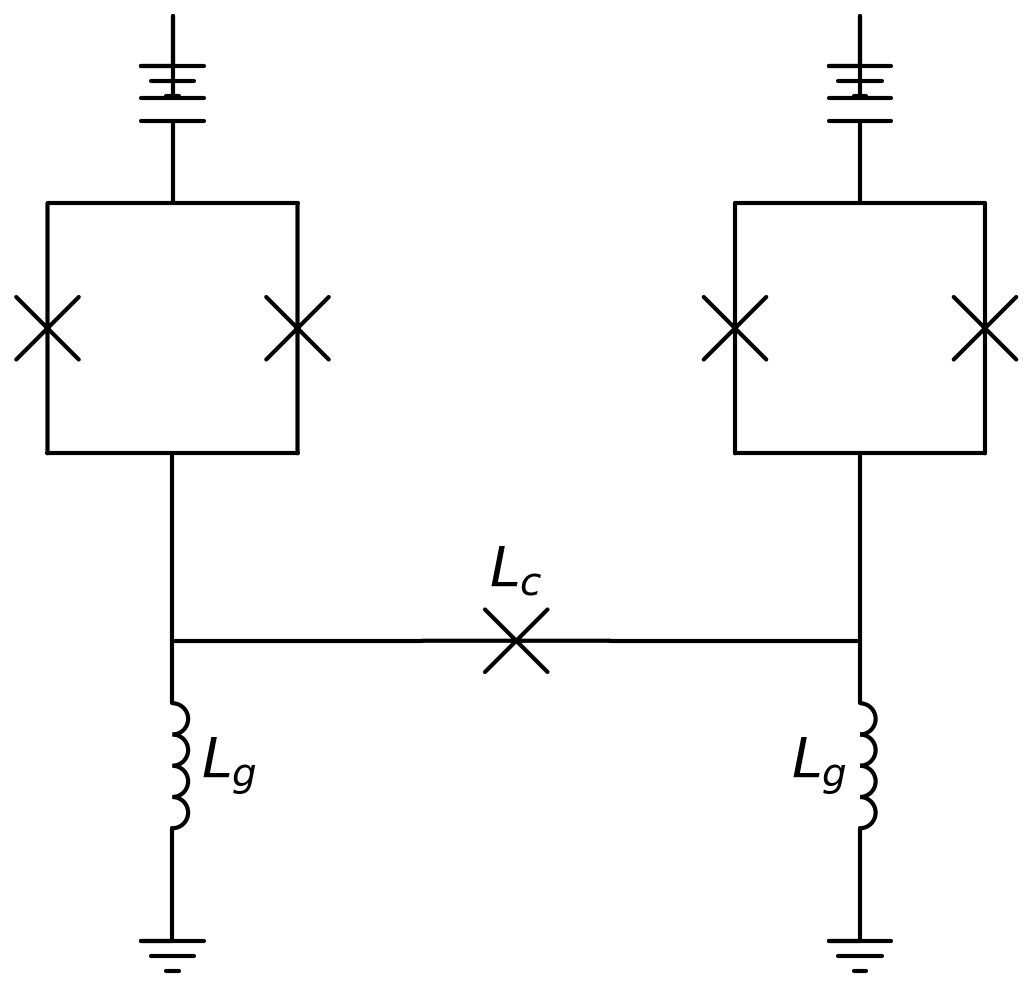

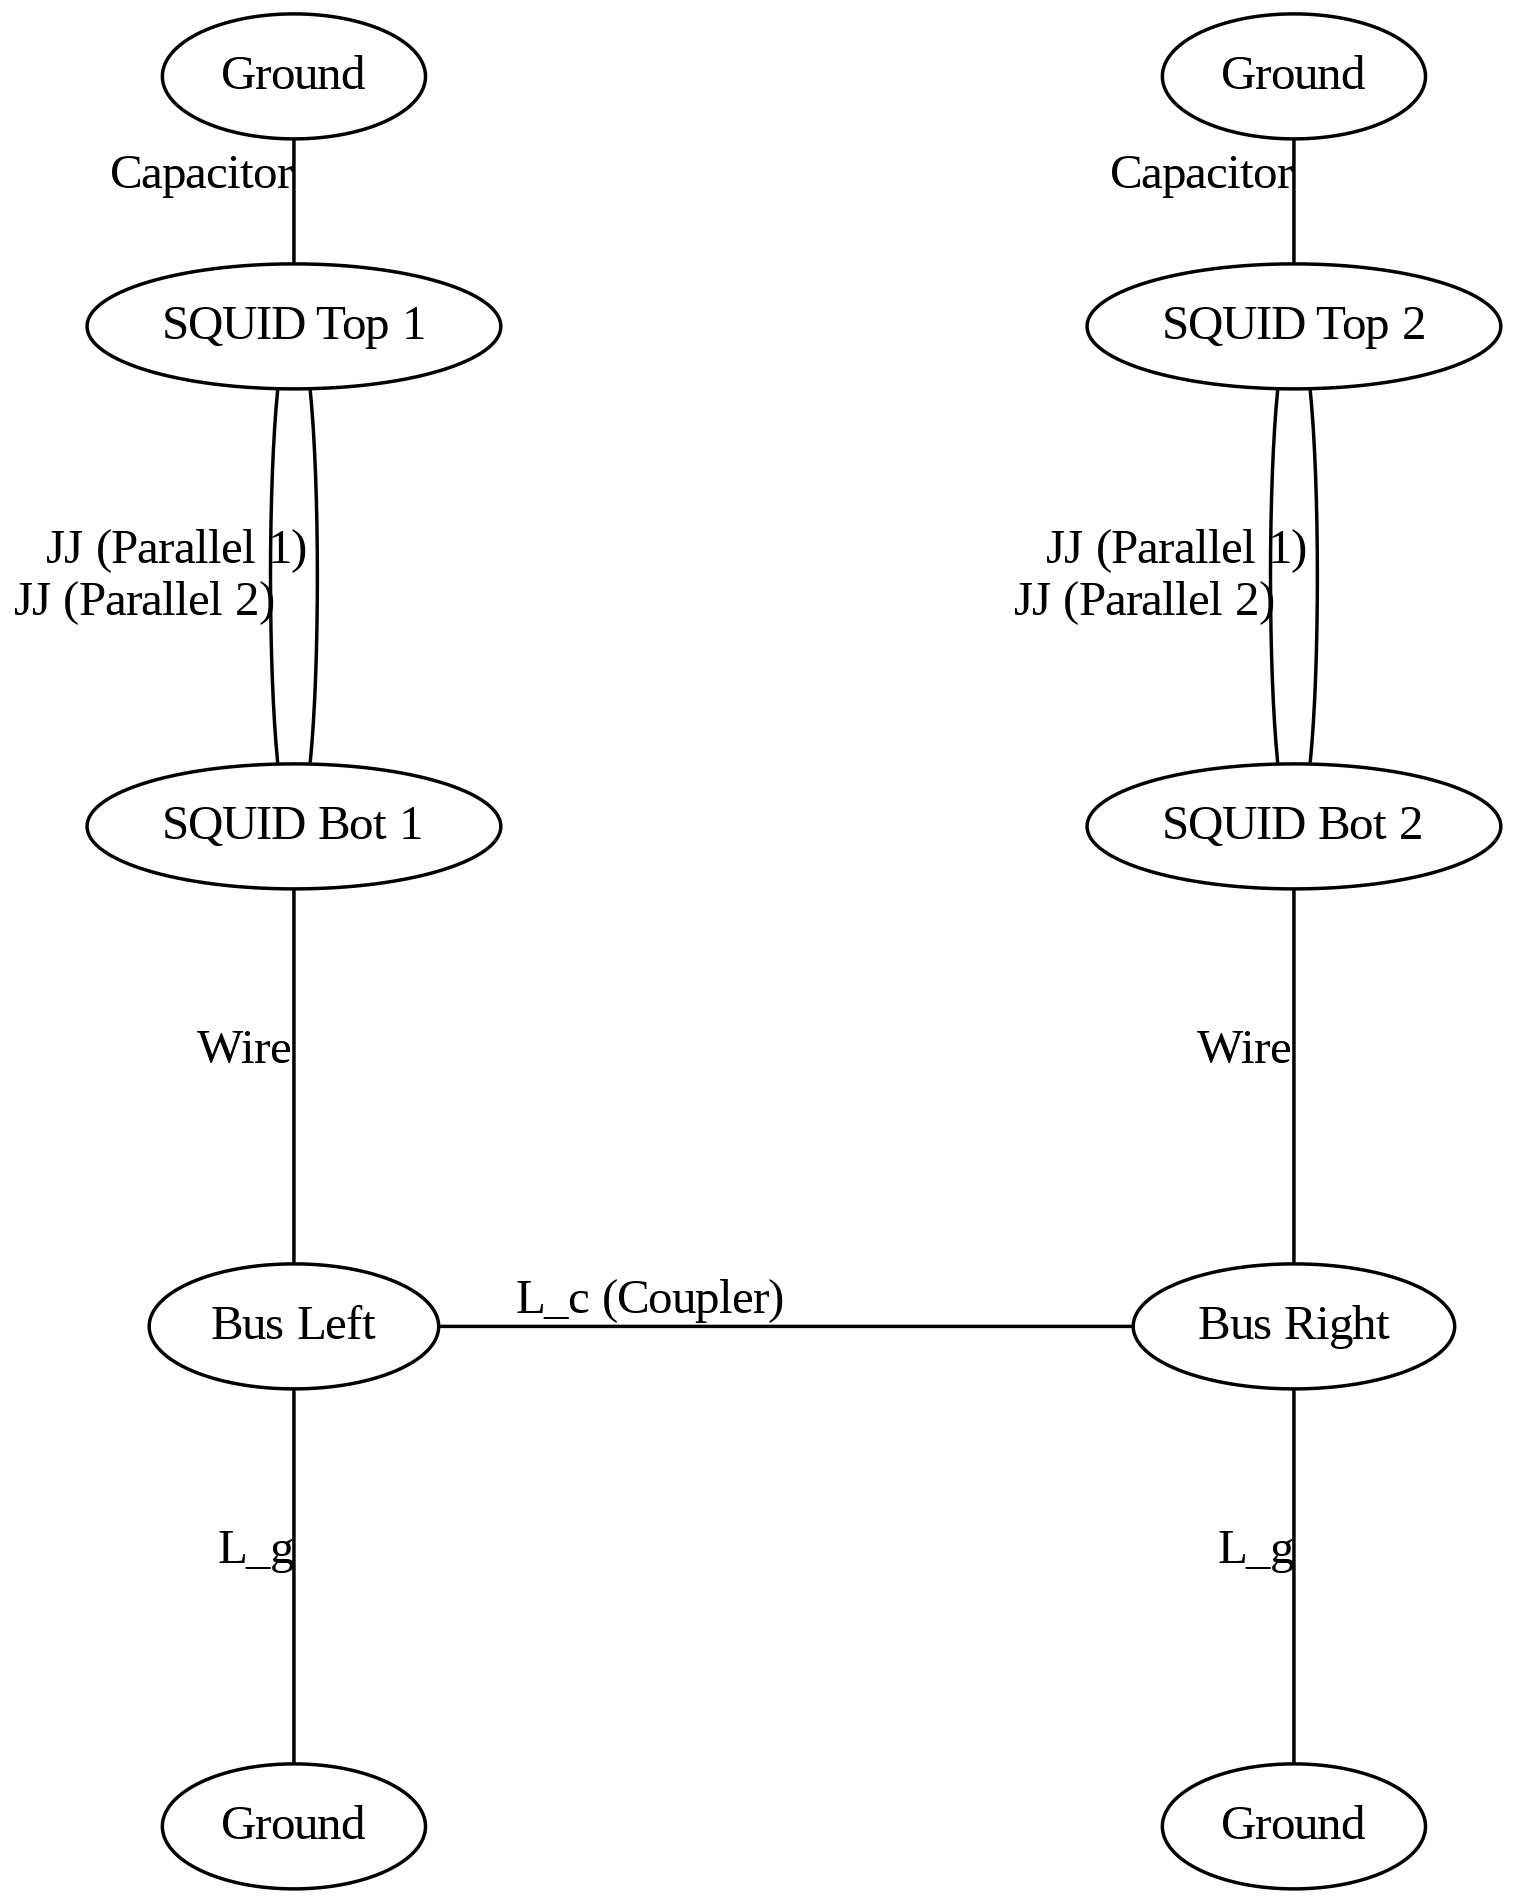

In [2]:
"""This script generates a schematic of a tunable gmon coupler between two qubits and its topological graph as inline raster images."""

import io
import matplotlib.pyplot as plt
import schemdraw
import schemdraw.elements as elm
import graphviz
from IPython.display import Image, display

# Control Knobs for Output Rendering
DPI_SETTING = 250
FONT_SANS_SERIF = ['Tahoma', 'DejaVu Sans']
FONT_WEIGHT = 'normal'
FIG_SIZE = (8, 5)

# Control Knobs for Geometric Proportions
LINE_LENGTH_SHORT = 1.0
LINE_LENGTH_MEDIUM = 1.5
LINE_LENGTH_LONG = 2.0

def configure_matplotlib_environment() -> None:
    """Configures the matplotlib runtime parameters for optimal inline rendering."""
    plt.rcParams['figure.dpi'] = DPI_SETTING
    plt.rcParams['font.sans-serif'] = FONT_SANS_SERIF
    plt.rcParams['font.weight'] = FONT_WEIGHT
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['figure.figsize'] = FIG_SIZE

def render_schemdraw_circuit() -> None:
    """Constructs and displays the tunable gmon coupler circuit as an inline PNG."""
    configure_matplotlib_environment()

    with schemdraw.Drawing() as drawing:
        drawing.config(fontsize=16, lw=1.2)

        # Left Qubit Assembly
        drawing += elm.Ground()
        drawing += elm.Capacitor().down().length(LINE_LENGTH_MEDIUM)
        top_center_left = drawing.here

        # Left SQUID Loop
        drawing += elm.Line().left().length(LINE_LENGTH_SHORT)
        drawing += elm.Josephson().down().length(LINE_LENGTH_LONG)
        drawing += elm.Line().right().length(LINE_LENGTH_SHORT)
        bottom_center_left = drawing.here

        drawing += elm.Line().at(top_center_left).right().length(LINE_LENGTH_SHORT)
        drawing += elm.Josephson().down().length(LINE_LENGTH_LONG)
        drawing += elm.Line().left().length(LINE_LENGTH_SHORT)

        # Left Inductive Ground Path
        drawing += elm.Line().at(bottom_center_left).down().length(LINE_LENGTH_MEDIUM)
        bus_node_left = drawing.here

        # Applying the 'bottom' parameter to a downward vector forces the label to the geometric left.
        drawing += elm.Inductor().down().length(LINE_LENGTH_LONG).label('$L_g$', loc='bottom')
        drawing += elm.Ground()

        # Central Coupling Element
        drawing += elm.Line().at(bus_node_left).right().length(LINE_LENGTH_LONG)
        drawing += elm.Josephson().right().length(LINE_LENGTH_MEDIUM).label('$L_c$', loc='top')
        drawing += elm.Line().right().length(LINE_LENGTH_LONG)
        bus_node_right = drawing.here

        # Coordinate mapping for Right Qubit symmetry
        x_right = bus_node_right[0]
        y_bus = bus_node_right[1]

        bottom_center_right = (x_right, y_bus + LINE_LENGTH_MEDIUM)
        top_center_right = (x_right, y_bus + LINE_LENGTH_MEDIUM + LINE_LENGTH_LONG)
        top_ground_right = (x_right, y_bus + LINE_LENGTH_MEDIUM + LINE_LENGTH_LONG + LINE_LENGTH_MEDIUM)

        # Right Qubit Assembly
        drawing += elm.Ground().at(top_ground_right)
        drawing += elm.Capacitor().down().length(LINE_LENGTH_MEDIUM)

        # Right SQUID Loop
        drawing += elm.Line().left().length(LINE_LENGTH_SHORT)
        drawing += elm.Josephson().down().length(LINE_LENGTH_LONG)
        drawing += elm.Line().right().length(LINE_LENGTH_SHORT)

        drawing += elm.Line().at(top_center_right).right().length(LINE_LENGTH_SHORT)
        drawing += elm.Josephson().down().length(LINE_LENGTH_LONG)
        drawing += elm.Line().left().length(LINE_LENGTH_SHORT)

        # Right Inductive Ground Path Connection
        drawing += elm.Line().at(bottom_center_right).down().length(LINE_LENGTH_MEDIUM)

        # Applying the 'top' parameter to a downward vector forces the label to the geometric right.
        drawing += elm.Inductor().at(bus_node_right).down().length(LINE_LENGTH_LONG).label('$L_g$', loc='top')
        drawing += elm.Ground()

        # Extract image data directly to avoid empty matplotlib buffers
        image_bytes = drawing.get_imagedata(fmt='png')
        display(Image(data=image_bytes, format='png'))

def generate_topological_graph() -> None:
    """Generates and displays a graphviz representation of the circuit topology as an inline PNG."""
    topology = graphviz.Graph(engine='neato')
    topology.attr(dpi=str(DPI_SETTING))

    # Defining nodes with strict coordinate placements to mirror the schematic
    topology.node('GND_TL', 'Ground', pos='0,5!')
    topology.node('Q1_T', 'SQUID Top 1', pos='0,4!')
    topology.node('Q1_B', 'SQUID Bot 1', pos='0,2!')
    topology.node('BUS_L', 'Bus Left', pos='0,0!')
    topology.node('GND_BL', 'Ground', pos='0,-2!')

    topology.node('GND_TR', 'Ground', pos='4,5!')
    topology.node('Q2_T', 'SQUID Top 2', pos='4,4!')
    topology.node('Q2_B', 'SQUID Bot 2', pos='4,2!')
    topology.node('BUS_R', 'Bus Right', pos='4,0!')
    topology.node('GND_BR', 'Ground', pos='4,-2!')

    # Defining connectivity edges
    topology.edge('GND_TL', 'Q1_T', label='Capacitor')
    topology.edge('Q1_T', 'Q1_B', label='JJ (Parallel 1)')
    topology.edge('Q1_T', 'Q1_B', label='JJ (Parallel 2)')
    topology.edge('Q1_B', 'BUS_L', label='Wire')
    topology.edge('BUS_L', 'GND_BL', label='L_g')

    topology.edge('BUS_L', 'BUS_R', label='L_c (Coupler)')

    topology.edge('GND_TR', 'Q2_T', label='Capacitor')
    topology.edge('Q2_T', 'Q2_B', label='JJ (Parallel 1)')
    topology.edge('Q2_T', 'Q2_B', label='JJ (Parallel 2)')
    topology.edge('Q2_B', 'BUS_R', label='Wire')
    topology.edge('BUS_R', 'GND_BR', label='L_g')

    # Generate the raw PNG byte stream and display it natively
    png_data = topology.pipe(format='png')
    display(Image(data=png_data, format='png'))

if __name__ == '__main__':
    render_schemdraw_circuit()
    generate_topological_graph()